<a href="https://colab.research.google.com/github/SithphawitSangkaha/Deep-Learning-class/blob/main/projects/DL(3_2)_66110043_Sithphawit_Sangkaha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tensorflow.keras import backend as K
from matplotlib.ticker import MaxNLocator
from IPython.display import clear_output
from scipy import optimize
from matplotlib.gridspec import GridSpec
from IPython.display import Image
from tensorflow.keras import initializers
from IPython.display import Javascript
from datetime import datetime
import os
import random
import time

SEED = 42

# Set the environment variables for reproducibility.
os.environ['TF_DETERMINISTIC_OPS'] = '1' # Enable deterministic operations. (TensorFlow가 연산을 수행할 때 매번 동일한 순서와 방식을 사용하도록 결정론적(Deterministic) 연산을 활성화합니다.)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # Force cuDNN to use deterministic algorithms. (GPU 연산 라이브러리인 cuDNN이 무작위성을 줄이고 결정론적 알고리즘만 사용하도록 강제합니다.)
os.environ['PYTHONHASHSEED'] = '0' # Fix Python hash seed for reproducibility. (파이썬의 문자열 및 객체 해시 생성 알고리즘에 고정된 시드(Seed)를 부여하여 무작위 요소를 제거합니다.)

# Set the environment variables for reproducibility.
tf.config.threading.set_inter_op_parallelism_threads(1) # 서로 독립적인 연산(Op)들을 동시에 병렬 처리할 때 사용할 쓰레드 수를 1개로 제한합니다.
tf.config.threading.set_intra_op_parallelism_threads(1) # 하나의 단일 연산(예: 대형 행렬 곱셈) 내부에서 멀티쓰레딩으로 나누어 처리할 쓰레드 수를 1개로 제한합니다.

# Set global random seeds
tf.random.set_seed(SEED) # 텐서플로 난수 생성기의 시드를 고정합니다.
np.random.seed(SEED) # 넘파이 난수 생성기의 시드를 고정합니다.
random.seed(SEED) # 파이썬 기본 random 모듈의 시드를 고정합니다.

initializer = tf.keras.initializers.GlorotNormal(seed=SEED) # 신경망 가중치 초기화 시 동일한 난수를 사용하도록 시드를 지정한 초기화 객체를 생성합니다.

In [ ]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# # x in [-2*pi, 2*pi]
# x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
# # Analytical solution
# def f(x):
#   return np.exp(-x**2) * np.sin(5*x) + np.tanh(x)*np.cos(10*x**2)
# y = f(x)
# 1. The Core Requirement: Self-Supervised PINN Loss Function
def pinn_loss(x_true, y_pred):
    # In self-supervised learning, we pass 'x' as both the input and the target.
    # Therefore, 'x_true' is actually our x input.
    # We dynamically calculate the analytical equation using TensorFlow operations:
    y_actual = tf.exp(-tf.square(x_true)) * tf.sin(5.0 * x_true) + \
               tf.tanh(x_true) * tf.cos(10.0 * tf.square(x_true))

    # Return the RMSE between the network's prediction and the equation's output
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_actual)))

In [ ]:
# Split into 800 training samples and 200 test samples

# Generate the full 1000 points
x_all = np.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)

# Split into 800 training and 200 testing samples
# Note: We are only splitting 'x' because we don't use 'y' labels for training
x_train, x_test = train_test_split(x_all, test_size=200, random_state=SEED)

In [ ]:
# 3. Model Architecture (Fourier Features + MLP)
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, num_features=256, scale=12.0, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.scale = scale

    def build(self, input_shape):
        self.b = self.add_weight(
            shape=(input_shape[-1], self.num_features),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.scale, seed=SEED),
            trainable=False,
            name='fourier_b'
        )
        super().build(input_shape)

    def call(self, inputs):
        proj = 2.0 * np.pi * tf.matmul(inputs, self.b)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)
#MLP
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(1,)),
    FourierFeatureMapping(num_features=128, scale=3.0),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
    tf.keras.layers.Dense(1, kernel_initializer=initializer)
])

In [ ]:
# Hyperparameters

learning_rate = 0.001
batch_size = 800
num_epochs = 3000

In [ ]:
# 4. Compilation and Training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=pinn_loss
)

In [ ]:
# 3. MONITOR 'LOSS' NOT 'VAL_LOSS'
# In self-supervised equation solving, the concept of "overfitting" the equation
# doesn't apply the same way. We want to force the training loss as close to 0 as possible.
lr_callback = ReduceLROnPlateau(
    monitor='loss', # Changed from val_loss
    factor=0.5,
    patience=50,
    #min_delta=1e-6,
    min_lr=1e-6,
    verbose=1
)
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    'best_model_v2.weights.h5',
    monitor='loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)
early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=300, # If the loss doesn't improve for 300 epochs, stop training immediately
    restore_best_weights=True, # Automatically loads the best weights so you don't have to
    verbose=1
)
history = model.fit(
    x=x_train,
    y=x_train, # Self-supervised: x is passed as the target
    validation_data=(x_test, x_test), # 200 samples used for test/validation
    epochs = num_epochs,
    batch_size = batch_size,
    callbacks=[lr_callback,
               checkpoint_callback,
               early_stop_callback
               ],
    verbose=0
)
model.load_weights('best_model_v2.weights.h5')

print("Best weights restored.")

Streaming output truncated to the last 5000 lines.

Epoch 1750: finished saving model to best_model_v2.weights.h5

Epoch 1751: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1751: finished saving model to best_model_v2.weights.h5

Epoch 1752: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1752: finished saving model to best_model_v2.weights.h5

Epoch 1753: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1753: finished saving model to best_model_v2.weights.h5

Epoch 1754: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1754: finished saving model to best_model_v2.weights.h5

Epoch 1755: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1755: finished saving model to best_model_v2.weights.h5

Epoch 1756: loss improved from 0.00147 to 0.00147, saving model to best_model_v2.weights.h5

Epoch 1756: 

In [ ]:
# 5. Output and Plotting Requirements
# Calculate explicit Test RMSE for the 200 test samples
y_pred_test = model.predict(x_test, verbose=0)
y_actual_test = np.exp(-x_test**2) * np.sin(5*x_test) + np.tanh(x_test)*np.cos(10*x_test**2)
test_rmse = np.sqrt(np.mean((y_pred_test - y_actual_test)**2))

print(f"AUTOMATIC TEST RMSE (200 Samples): {test_rmse:.6f}")

AUTOMATIC TEST RMSE (200 Samples): 0.116094


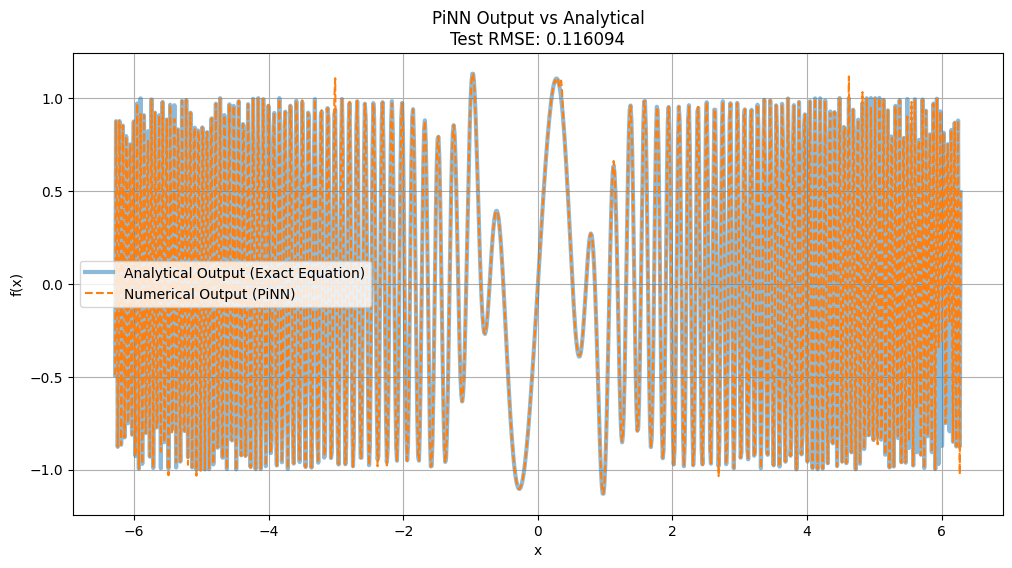

In [ ]:
# For plotting, we predict on the ENTIRE sorted dataset (x_all)
# so the plotted lines are smooth and continuous, matching the assignment image.
y_pred_all = model.predict(x_all, verbose=0)
y_actual_all = np.exp(-x_all**2) * np.sin(5*x_all) + np.tanh(x_all)*np.cos(10*x_all**2)

plt.figure(figsize=(12, 6))
plt.plot(x_all, y_actual_all, label="Analytical Output (Exact Equation)", color="tab:blue", linewidth=3, alpha=0.5)
plt.plot(x_all, y_pred_all, label="Numerical Output (PiNN)", color="tab:orange", linestyle="--", linewidth=1.5)

plt.title(f"PiNN Output vs Analytical\nTest RMSE: {test_rmse:.6f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

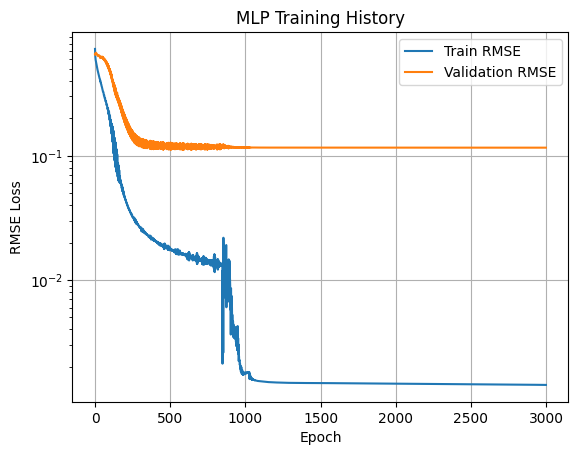

In [ ]:
# Plot training loss

plt.plot(history.history['loss'], label='Train RMSE')
plt.plot(history.history['val_loss'], label='Validation RMSE')

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.title('MLP Training History')

plt.legend()
plt.grid(True)
plt.show()